# Mini Project 5-2 Explore Probability Distributions

## **Introduction**

The ability to determine which type of probability distribution best fits data, calculate z-score, and detect outliers are essential skills in data work. These capabilities enable data professionals to understand how their data is distributed and identify data points that need further examination.

In this activity, you are a member of an analytics team for the United States Environmental Protection Agency (EPA). The data includes information about more than 200 sites, identified by state, county, city, and local site names. One of your main goals is to determine which regions need support to make air quality improvements. Given that carbon monoxide is a major air pollutant, you will investigate data from the Air Quality Index (AQI) with respect to carbon monoxide.

## **Step 1: Imports** 

Import relevant libraries, packages, and modules. For this Project, you will need `numpy`, `pandas`, `matplotlib.pyplot`, `statsmodels.api`, and `scipy`.

In [1]:
# Import relevant libraries, packages, and modules.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

A subset of data was taken from the air quality data collected by the EPA, then transformed to suit the purposes of this lab. This subset is a .csv file named `modified_c4_epa_air_quality.csv`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

air_quality = pd.read_csv("modified_c4_epa_air_quality.csv")
air_quality.head()

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294


## **Step 2: Data exploration** 

Display the first 10 rows of the data to get a sense of how the data is structured.

In [3]:
# Display first 10 rows of the data.

air_quality.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294
5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,2.708050
6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,1.098612
7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,1.098612
8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,1.791759
9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,1.945910


The `aqi_log` column represents AQI readings that were transformed logarithmically to suit the objectives of this lab. Taking a logarithm of the aqi to get a bell-shaped distribution is outside the scope of this course, but is helpful to see the normal distribution.

To better understand the quantity of data you are working with, display the number of rows and the number of columns.

In [4]:
# Display number of rows, number of columns.

air_quality.shape

(260, 8)

Now, you want to find out whether `aqi_log` fits a specific type of probability distribution. Create a histogram to visualize the distribution of `aqi_log`. Then, based on its shape, visually determine if it resembles a particular distribution.

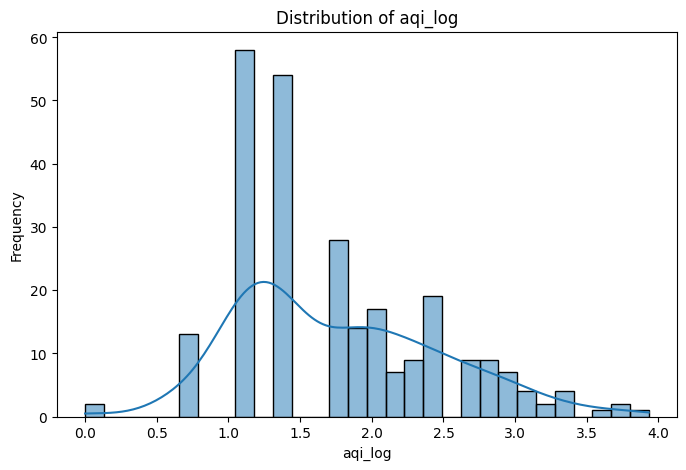

In [6]:
# Create a histogram to visualize distribution of aqi_log.

plt.figure(figsize=(8,5))
sns.histplot(air_quality["aqi_log"], bins=30, kde=True)
plt.title("Distribution of aqi_log")
plt.xlabel("aqi_log")
plt.ylabel("Frequency")
plt.show()

**Question:** What do you observe about the shape of the distribution from the histogram? 

A: The distribution is right skewed, lot of smaller peaks but a central main peak = moderate variability. The skewness shows most areas have relatively low aqi_log values, some higher -> more analysis needed.

## **Step 3: Statistical tests**

Use the empirical rule to observe the data, then test and verify that it is normally distributed.


 As you have learned, the empirical rule states that, for every normal distribution: 
- 68% of the data fall within 1 standard deviation of the mean
- 95% of the data fall within 2 standard deviations of the mean
- 99.7% of the data fall within 3 standard deviations of the mean


First, define two variables to store the mean and standard deviation, respectively, for `aqi_log`. Creating these variables will help you easily access these measures as you continue with the calculations involved in applying the empirical rule. 

In [7]:
# Define variable for aqi_log mean.

aqi_log_mean = air_quality["aqi_log"].mean()

# Print out the mean.

print("Mean of aqi_log:", aqi_log_mean)

Mean of aqi_log: 1.7669210929985582


In [8]:
# Define variable for aqi_log standard deviation.

aqi_log_std = air_quality["aqi_log"].std()

# Print out the standard deviation.

print("Standard deviatiion of aqi_log:", aqi_log_std)


Standard deviatiion of aqi_log: 0.7147155520223721


Now, check the first part of the empirical rule: whether 68% of the `aqi_log` data falls within 1 standard deviation of the mean.

To compute the actual percentage of the data that satisfies this criteria, define the lower limit (for example, 1 standard deviation below the mean) and the upper limit (for example, 1 standard deviation above the mean). This will enable you to create a range and confirm whether each value falls within it.

In [9]:
# Define variable for lower limit, 1 standard deviation below the mean.

lower_limit = aqi_log_mean - aqi_log_std

# Define variable for upper limit, 1 standard deviation above the mean.

upper_limit = aqi_log_mean + aqi_log_std

# Display lower_limit, upper_limit.

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)


Lower limit: 1.052205540976186
Upper limit: 2.4816366450209304


In [10]:
# Display the actual percentage of data that falls within 1 standard deviation of the mean.

within_1_std = air_quality[
    (air_quality["aqi_log"] >= lower_limit) &
    (air_quality["aqi_log"] <= upper_limit)
]

percentage_within_1_std = (len(within_1_std) / len(air_quality)) * 100
print(f"Percentage within 1 standard deviation: {percentage_within_1_std:.2f}%")

Percentage within 1 standard deviation: 76.15%


Now, consider the second part of the empirical rule: whether 95% of the `aqi_log` data falls within 2 standard deviations of the mean.

To compute the actual percentage of the data that satisfies this criteria, define the lower limit (for example, 2 standard deviations below the mean) and the upper limit (for example, 2 standard deviations above the mean). This will enable you to create a range and confirm whether each value falls within it.

In [11]:
# Define variable for lower limit, 2 standard deviations below the mean.

lower_limit_2std = aqi_log_mean - 2 * aqi_log_std

# Define variable for upper limit, 2 standard deviations below the mean.

upper_limit_2std = aqi_log_mean + 2 * aqi_log_std

# Display lower_limit, upper_limit.

print("Lower limit (2 std):", lower_limit_2std)
print("Upper limit (2 std):", upper_limit_2std)

Lower limit (2 std): 0.3374899889538139
Upper limit (2 std): 3.1963521970433026


In [12]:
# Display the actual percentage of data that falls within 2 standard deviations of the mean.

within_2_std = air_quality[
    (air_quality["aqi_log"] >= lower_limit_2std) &
    (air_quality["aqi_log"] <= upper_limit_2std)
]

percentage_within_2_std = (len(within_2_std) / len(air_quality)) * 100
print(f"Percentage within 2 standard deviations: {percentage_within_2_std:.2f}%")

Percentage within 2 standard deviations: 95.77%


Now, consider the third part of the empirical rule:whether 99.7% of the `aqi_log` data falls within 3 standard deviations of the mean.

To compute the actual percentage of the data that satisfies this criteria, define the lower limit (for example, 3 standard deviations below the mean) and the upper limit (for example, 3 standard deviations above the mean). This will enable you to create a range and confirm whether each value falls within it.

In [13]:
# Define variable for lower limit, 3 standard deviations below the mean.

lower_limit_3std = aqi_log_mean - 3 * aqi_log_std


# Define variable for upper limit, 3 standard deviations above the mean.

upper_limit_3std = aqi_log_mean + 3 * aqi_log_std

# Display lower_limit, upper_limit.

print("Lower limit (3 std):", lower_limit_3std)
print("Upper limit (3 std):", upper_limit_3std)

Lower limit (3 std): -0.37722556306855815
Upper limit (3 std): 3.9110677490656744


In [14]:
# Display the actual percentage of data that falls within 3 standard deviations of the mean.

within_3_std = air_quality[
    (air_quality["aqi_log"] >= lower_limit_3std) &
    (air_quality["aqi_log"] <= upper_limit_3std)
]

percentage_within_3_std = (len(within_3_std) / len(air_quality)) * 100
print(f"Percentage within 3 standard deviations: {percentage_within_3_std:.2f}%")

Percentage within 3 standard deviations: 99.62%


## **Step 4: Results and evaluation** 

**Question:** What results did you attain by applying the empirical rule? 

A: Within 1 standard deviation: approximately 76% of the data fell within 1 standard deviation of the mean; 2: Approximately 95% fell within 2 standard deviations; 3: Approximately 99% fell within 3 standard deviations. 

Distribution is approximately normal even though the histogram showed a slight right skew. 

**Question:** How would you use z-score to find outliers? 

A: You measure how many standard deviations a value is from the mean. 

Compute the z-score for every `aqi_log` value. Then, add a column named `z_score` in the data to store those results. 

In [16]:
# Compute the z-score for every aqi_log value, and add a column named z_score in the data to store those results.

 # ddof=degrees of freedom correction (sample vs. population)

from scipy.stats import zscore

air_quality["z_score"] = zscore(air_quality["aqi_log"], ddof=1)

# Display the first 5 rows to ensure that the new column was added.
air_quality.head(5)


,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log,z_score
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442,0.437265
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759,0.034753
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612,-0.935070
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294,-0.532557
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294,-0.532557


Identify the parts of the data where `aqi_log` is above or below 3 standard deviations of the mean.

In [17]:
# Display data where `aqi_log` is above or below 3 standard deviations of the mean

outliers = air_quality[(air_quality["z_score"] > 3) | (air_quality["z_score"] < -3)]

outliers

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log,z_score
244,2018-01-01,Arizona,Maricopa,Phoenix,WEST PHOENIX,Carbon monoxide,Parts per million,3.931826,3.029044


**Question:** What do you observe about potential outliers based on the calculations?


A: There are only a few data points with z-scores above or below 3, which means that extreme outliers are rare. 

**Question:** Why is outlier detection an important part of this project? 

A: Outlier detection is important because outliers can distort summmary statistics and skew analysis results. 

## **Considerations**

**What are some key takeaways that you learned during this lab?**

A: I learned how to apply the empirical rule and z-scores to analyze the distribution of air quality data and identify potential outliers. These help confirm that the data is mostly normal with a few extreme values that should have further analysis. 

**What summary would you provide to audiences? Consider the distribution of the data and which sites would benefit from additional research.**

A: The aqi_log data is slightly right-skewed but mostly follows a normal distribution, with the majority of values falling within expected ranges. Sites identified as outliers - ones with unsually high aqi_log values would benefit from additional research/analysis to understand sources of air polution. 

**Reference**

US EPA, OAR. 2014, July 8. [Air Data: Air Quality Data Collected at Outdoor Monitors Across the US](https://www.epa.gov/outdoor-air-quality-data). 